# Fig 2e edits — short-event ridge / main-sequence diagnostics

Lizard paper events (`configs/paper_blocks.yaml`). Same amp/V filters as Fig 2e.

**What this answers.** Peak V vs amplitude shows a steep diagonal ridge. That is not the
0.8°/frame detection floor (that floor is **horizontal** at 0.048 deg/ms). For an event
of detector `length` L (inter-frame intervals), the duration identity is

$$V_{\mathrm{id}} = A / (L \cdot \Delta t),\qquad \Delta t = 1000/\mathrm{fps}\ \mathrm{ms}.$$

Length-1 events (shortest legal run, 2 samples) pile on $V = A/16.7\,\mathrm{ms}$. Longer
events can still sit on their own $L$-identity when peak ≈ mean speed over L frames.

**This notebook** writes diagnostic plot bundles (does not change the production `2e`
catalog exporter):

| PDF | Content |
|---|---|
| `figure_2e_scatter_by_length.pdf` | Pooled scatter colored by length |
| `2e_all_animals_gray.pdf` | Same points, gray, α=0.5 |
| `2e_per_animal_gray.pdf` | Multi-page per-animal gray |
| `fig_2e_mono_conc_all.pdf` | 1×3 Fig 2e means: all / concurrent / monocular |
| `omission_trial/` | Same bundle after dropping length ≤ `OMISSION_MAX_LENGTH` |
| `2e_omit_identity_gray.pdf` | Gray scatter after dropping on-identity samples (±1% of $V=A/(L\Delta t)$) |
| `2e_amp_original_vs_pre_onset.pdf` | Side-by-side: original A vs pre-onset A (§3d) |

Overlays: detection floor + OLS (no 1-frame identity line on the gray scatters).

Kernel: `eye_repo_mac`. From the repo root, `PYTHONPATH=src`. Lab volume must be mounted
for a cache miss; a hit under `outputs/review_answers_latest/metadata/event_cache/` is enough.


## 0. Setup


In [2]:
%matplotlib inline
from __future__ import annotations

import os
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.ioff()

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "eye_tracking_system_tools").is_dir():
            REPO = p
            break

sys.path.insert(0, str(REPO / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from eye_tracking_system_tools.analysis.block_registry import load_registry
from eye_tracking_system_tools.analysis.diagnostics_2e import (
    OMISSION_MAX_LENGTH as DEFAULT_OMISSION_MAX_LENGTH,
    attach_pre_event_amplitude,
    collect_2e_length_points,
    export_diagnostics_2e,
    length_identity_summary,
    on_length_identity_mask,
)
from eye_tracking_system_tools.analysis.event_cache import (
    build_or_load_event_tables,
    ensure_traces_for_blocks,
)
from eye_tracking_system_tools.analysis.export_meta import load_params_yaml
from eye_tracking_system_tools.analysis.review_collect import review_answers_dir
from eye_tracking_system_tools.analysis.run_layout import resolve_figure_dirs

# Empty TAG overwrites outputs/review_answers_latest
TAG = ""
REGISTRY = REPO / "configs" / "paper_blocks.yaml"
PARAMS_YAML = REPO / "configs" / "analysis_params.yaml"
run = review_answers_dir(REPO / "outputs", TAG)
OUT = run / "diagnostics_2e"
figures_dir, metadata_dir = resolve_figure_dirs(OUT)
cache_dir = run / "metadata"
cache_dir.mkdir(parents=True, exist_ok=True)
print("REPO :", REPO)
print("run  :", run)
print("plot :", OUT)
print("  figures :", figures_dir)
print("  metadata:", metadata_dir)
print("  cache   :", cache_dir / "event_cache")


REPO : /Users/nimi/Projects/PETS
run  : /Users/nimi/Projects/PETS/outputs/review_answers_latest
plot : /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e
  figures : /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/plots
  metadata: /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/metadata
  cache   : /Users/nimi/Projects/PETS/outputs/review_answers_latest/metadata/event_cache


## 1. PARAMS (fidget surface)

Re-run from here down after edits. Defaults match lizard Fig 2e / the diagnostic exporter.


In [3]:
# --- Fig 2e amp / V filters ---
AMP_COL = "net_angular_disp"
MIN_AMP_DEG = 0.5
MAX_AMP_PCT = 99.5
FRAME_RATE_FPS = 60.0
BIN_WIDTH_DEG = 5.0
MIN_EVENTS_PER_BIN = 15

# --- detection (only matters on cache miss / re-detect) ---
SPEED_THRESHOLD_DEG_PER_FRAME = 0.8

# --- gray scatter look ---
GRAY_ALPHA = 0.5
GRAY_COLOR = "0.45"
GRAY_SIZE = 6

# --- omission_trial: drop detector length ≤ this (1–2 = short-event ridge) ---
OMISSION_MAX_LENGTH = int(DEFAULT_OMISSION_MAX_LENGTH)  # default 2

# --- identity-line diagnostic: |V - A/(L·Δt)| ≤ max(ABS_TOL, REL_TOL · V_id) ---
IDENTITY_REL_TOL = 0.05   # 5% of identity V (table in §3)
IDENTITY_ABS_TOL = 0.002  # deg/ms floor on the tolerance

# --- omit-identity plot (§3c): drop samples within this relative margin of V=A/(L·Δt) ---
IDENTITY_OMIT_REL_TOL = 0.01  # 1% margin
IDENTITY_OMIT_ABS_TOL = 0.0   # pure relative cut; set >0 to add a floor

# --- output ---
SHOW_INLINE = True
RUN_EXPORT = True         # False → collect + identity table only (no PDF rewrite)
RUN_OMISSION = True       # exporter always writes omission_trial/; keep True for the bundle
SAVE_IDENTITY_OMIT_PDF = True
SAVE_AMP_PRE_COMPARE_PDF = True  # §3d side-by-side original vs pre-onset A


## 2. Load event tables

Events only (no traces). Cache hit is normal after a prior review-answers / paper run.


In [4]:
params = load_params_yaml(PARAMS_YAML)
ms = dict(params.get("main_sequence") or {})
ms.update(
    {
        "amp_col": AMP_COL,
        "min_amp_deg": float(MIN_AMP_DEG),
        "max_amp_pct": float(MAX_AMP_PCT),
        "frame_rate_fps": float(FRAME_RATE_FPS),
        "bin_width_deg": float(BIN_WIDTH_DEG),
        "min_events_per_bin": int(MIN_EVENTS_PER_BIN),
    }
)
sacc = dict(params.get("saccade") or {})
sacc["speed_threshold_deg_per_frame"] = float(SPEED_THRESHOLD_DEG_PER_FRAME)
params = {**params, "main_sequence": ms, "saccade": sacc}

specs = load_registry(REGISTRY)
tables, cache_path, from_cache = build_or_load_event_tables(
    specs,
    params,
    cache_dir,
    keep_traces=False,
    prefer_finalized=True,
)
print(
    f"blocks={len(tables.blocks)}  events={len(tables.all_saccades)}  "
    f"cache={'hit' if from_cache else 'miss'}"
)
print(cache_path)
animals = sorted(tables.all_saccades["animal"].astype(str).unique())
print("animals:", animals)
print("has length:", "length" in tables.all_saccades.columns)


blocks=23  events=36084  cache=hit
/Users/nimi/Projects/PETS/outputs/review_answers_latest/metadata/event_cache/7f648b1977bfa79e77e475f438169b8546fddc25.pkl
animals: ['PV_106', 'PV_126', 'PV_143', 'PV_57', 'PV_62']
has length: True


## 3. Length-identity diagnostic

For each length bin: $n$, how many lie on that length’s identity $V = A/(L\Delta t)$,
% of the bin, and % of the filtered dataset. Tolerance knobs are in §1.

Interpretation cue: length-1 on-identity ≈ events whose peak step **is** the net
displacement. Points **above** identity have an incoming pre-event step larger than net $A$.


In [5]:
df, diag_params = collect_2e_length_points(tables)
frame_ms = float(diag_params["frame_ms"])
amp_col = str(diag_params["amp_col"])
print(
    f"filtered n={len(df)}  cohort={diag_params['cohort']}  "
    f"frame_ms={frame_ms:.4f}  detect_floor={diag_params['speed_threshold_deg_per_ms']:.4f} deg/ms"
)

ident = length_identity_summary(
    df,
    amp_col=amp_col,
    frame_ms=frame_ms,
    rel_tol=float(IDENTITY_REL_TOL),
    abs_tol=float(IDENTITY_ABS_TOL),
)
display_cols = [
    "length_bin",
    "n",
    "n_on_identity",
    "pct_of_bin",
    "pct_of_all",
    "pct_bin_of_all",
    "identity_slope_deg_per_ms",
]
show = ident[display_cols].copy()
for c in ("pct_of_bin", "pct_of_all", "pct_bin_of_all"):
    show[c] = show[c].map(lambda x: f"{x:5.1f}%" if np.isfinite(x) else "—")
show["identity_slope_deg_per_ms"] = show["identity_slope_deg_per_ms"].map(
    lambda x: f"{x:.4f}" if np.isfinite(x) else "(per-event L)"
)
print(
    f"identity tolerance: rel={IDENTITY_REL_TOL:.3f}  abs={IDENTITY_ABS_TOL:.4f} deg/ms"
)
print(show.to_string(index=False))

ident_csv = metadata_dir / "length_identity_summary.csv"
metadata_dir.mkdir(parents=True, exist_ok=True)
ident.to_csv(ident_csv, index=False)
print("wrote", ident_csv)


filtered n=34336  cohort=pogona  frame_ms=16.6667  detect_floor=0.0480 deg/ms
identity tolerance: rel=0.050  abs=0.0020 deg/ms
length_bin     n  n_on_identity pct_of_bin pct_of_all pct_bin_of_all identity_slope_deg_per_ms
         1 11218           2647      23.6%       7.7%          32.7%                    0.0600
         2  9019            116       1.3%       0.3%          26.3%                    0.0300
         3  5954              4       0.1%       0.0%          17.3%                    0.0200
         4  3563              2       0.1%       0.0%          10.4%                    0.0150
         5  2095              0       0.0%       0.0%           6.1%                    0.0120
       6–8  2053              0       0.0%       0.0%           6.0%             (per-event L)
        9+   434              0       0.0%       0.0%           1.3%             (per-event L)
       ALL 34336           2769       8.1%       8.1%         100.0%             (per-event L)
wrote /Users/nimi/

### 3b. Optional: identity lines on the length-colored scatter (inline only)

Does not overwrite exported PDFs. Draws $V = A/(L\Delta t)$ for L = 1…5.


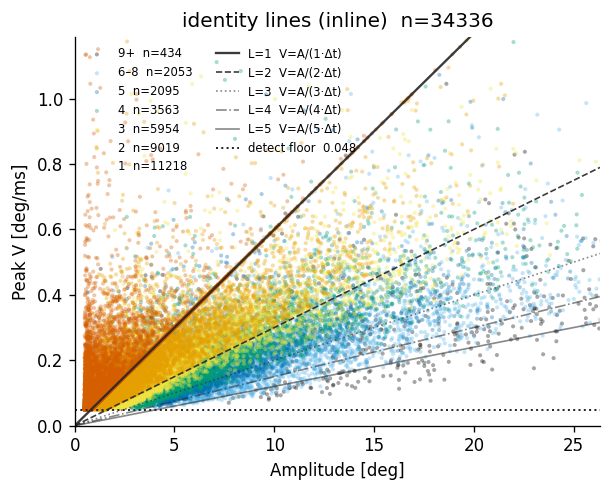

In [6]:
from eye_tracking_system_tools.analysis.diagnostics_2e import LENGTH_COLORS, LENGTH_DRAW_ORDER

amp = df[amp_col].to_numpy(dtype=float)
vel = df["peak_velocity_deg_per_ms"].to_numpy(dtype=float)
length_bin = df["length_bin"].to_numpy()
xmax = float(np.nanpercentile(amp, 99.8))
ymax = float(np.nanpercentile(vel, 99.8))
xlim = (0.0, max(xmax * 1.05, 1.0))
ylim = (0.0, max(ymax * 1.08, 0.1))

fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=120)
for label in LENGTH_DRAW_ORDER:
    mask = length_bin == label
    if not np.any(mask):
        continue
    ax.scatter(
        amp[mask],
        vel[mask],
        s=6,
        alpha=0.35,
        color=LENGTH_COLORS[label],
        edgecolors="none",
        rasterized=True,
        label=f"{label}  n={int(mask.sum())}",
    )
xs = np.linspace(0.0, xlim[1], 80)
for L, ls in ((1, "-"), (2, "--"), (3, ":"), (4, "-."), (5, "-")):
    ax.plot(
        xs,
        xs / (L * frame_ms),
        color="0.15",
        lw=1.0 if L > 1 else 1.4,
        ls=ls,
        alpha=0.9 if L <= 2 else 0.55,
        label=f"L={L}  V=A/({L}·Δt)",
    )
thr = float(diag_params["speed_threshold_deg_per_ms"])
ax.axhline(thr, color="0.15", lw=1.2, ls=":", label=f"detect floor  {thr:.3f}")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel("Amplitude [deg]")
ax.set_ylabel("Peak V [deg/ms]")
ax.set_title(f"identity lines (inline)  n={len(df)}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=7, loc="upper left", ncol=2)
fig.tight_layout()
if SHOW_INLINE:
    from IPython.display import display

    display(fig)
plt.close(fig)


### 3c. Omit identity subpopulation (1% margin)

For **each** event’s own detector length $L$, drop samples with

$$|V - A/(L\cdot\Delta t)| \le \texttt{IDENTITY\_OMIT\_REL\_TOL}\cdot A/(L\cdot\Delta t)$$

(default 1%). Remaining points = off-identity cloud. Saves a gray PDF next to the
diagnostic bundle and prints OLS before/after.


identity omit  rel_tol=0.010  abs_tol=0  n_full=34336  dropped=2410 (7.0%)  keep=31926
length_bin     n  n_dropped  pct_of_bin
         1 11218       2398   21.376359
         2  9019         12    0.133052
         3  5954          0    0.000000
         4  3563          0    0.000000
         5  2095          0    0.000000
       6–8  2053          0    0.000000
        9+   434          0    0.000000
OLS full:  slope=0.0220  r=0.668   |   OLS omit-identity: slope=0.0212  r=0.663
wrote /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/plots/2e_omit_identity_gray.pdf
wrote /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/metadata/identity_omit_drop_counts.csv


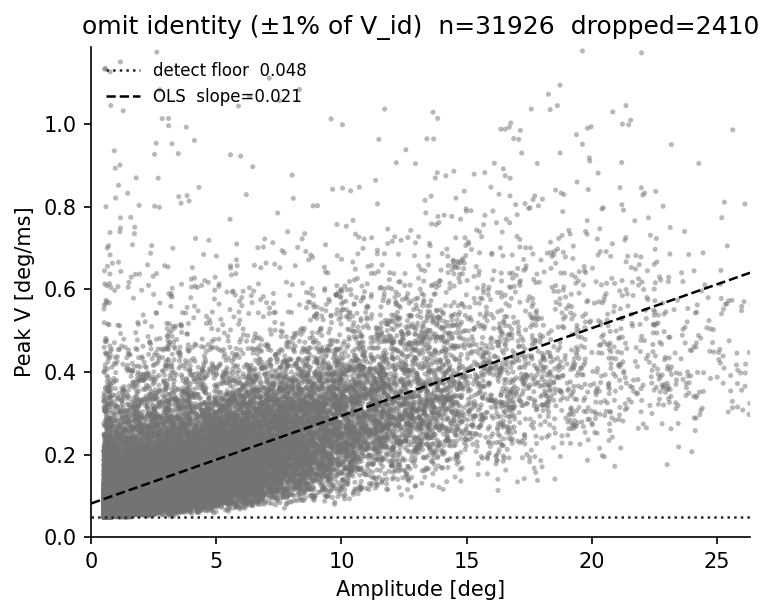

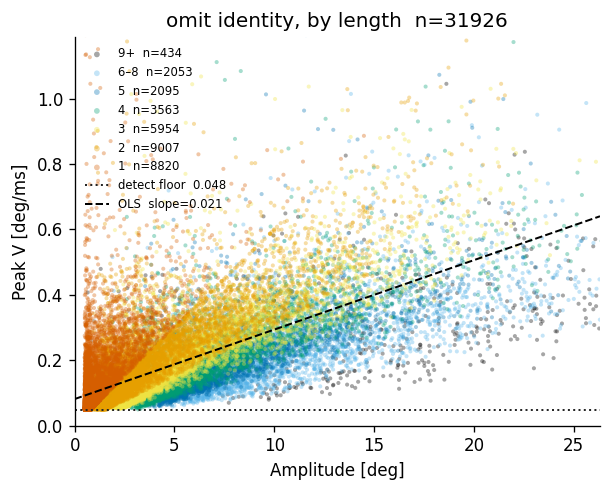

In [7]:
from scipy import stats

from eye_tracking_system_tools.analysis.diagnostics_2e import LENGTH_COLORS, LENGTH_DRAW_ORDER

on_id = on_length_identity_mask(
    df,
    amp_col=amp_col,
    frame_ms=frame_ms,
    rel_tol=float(IDENTITY_OMIT_REL_TOL),
    abs_tol=float(IDENTITY_OMIT_ABS_TOL),
)
df_off = df.loc[~on_id].copy()
n_full, n_drop, n_keep = int(len(df)), int(on_id.sum()), int((~on_id).sum())
print(
    f"identity omit  rel_tol={IDENTITY_OMIT_REL_TOL:.3f}  abs_tol={IDENTITY_OMIT_ABS_TOL:.4g}  "
    f"n_full={n_full}  dropped={n_drop} ({100.0 * n_drop / n_full:.1f}%)  keep={n_keep}"
)

# Per-length drop counts (same bins as §3)
drop_rows = []
for label, (lo, hi) in [
    ("1", (1, 1)),
    ("2", (2, 2)),
    ("3", (3, 3)),
    ("4", (4, 4)),
    ("5", (5, 5)),
    ("6–8", (6, 8)),
    ("9+", (9, 10_000)),
]:
    in_bin = (df["length"] >= lo) & (df["length"] <= hi)
    n_bin = int(in_bin.sum())
    n_bin_drop = int((in_bin & on_id).sum())
    drop_rows.append(
        {
            "length_bin": label,
            "n": n_bin,
            "n_dropped": n_bin_drop,
            "pct_of_bin": (100.0 * n_bin_drop / n_bin) if n_bin else float("nan"),
        }
    )
drop_tbl = pd.DataFrame(drop_rows)
print(drop_tbl.to_string(index=False))

amp_f = df[amp_col].to_numpy(dtype=float)
vel_f = df["peak_velocity_deg_per_ms"].to_numpy(dtype=float)
amp_k = df_off[amp_col].to_numpy(dtype=float)
vel_k = df_off["peak_velocity_deg_per_ms"].to_numpy(dtype=float)
slope_f, intercept_f, r_f, _, _ = stats.linregress(amp_f, vel_f)
slope_k, intercept_k, r_k, _, _ = stats.linregress(amp_k, vel_k)
print(
    f"OLS full:  slope={slope_f:.4f}  r={r_f:.3f}   |   "
    f"OLS omit-identity: slope={slope_k:.4f}  r={r_k:.3f}"
)

xmax = float(np.nanpercentile(amp_f, 99.8))
ymax = float(np.nanpercentile(vel_f, 99.8))
xlim = (0.0, max(xmax * 1.05, 1.0))
ylim = (0.0, max(ymax * 1.08, 0.1))
thr = float(diag_params["speed_threshold_deg_per_ms"])
xs = np.linspace(0.0, xlim[1], 80)

# Gray: kept only
fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=150)
ax.scatter(
    amp_k,
    vel_k,
    s=float(GRAY_SIZE),
    alpha=float(GRAY_ALPHA),
    color=str(GRAY_COLOR),
    edgecolors="none",
    rasterized=True,
)
ax.axhline(thr, color="0.15", lw=1.2, ls=":", label=f"detect floor  {thr:.3f}")
ax.plot(xs, slope_k * xs + intercept_k, "k--", lw=1.2, label=f"OLS  slope={slope_k:.3f}")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel("Amplitude [deg]")
ax.set_ylabel("Peak V [deg/ms]")
ax.set_title(
    f"omit identity (±{100 * IDENTITY_OMIT_REL_TOL:.0f}% of V_id)  "
    f"n={n_keep}  dropped={n_drop}"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

pdf_gray = figures_dir / "2e_omit_identity_gray.pdf"
if SAVE_IDENTITY_OMIT_PDF:
    figures_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(pdf_gray, format="pdf", bbox_inches="tight")
    print("wrote", pdf_gray)
    drop_tbl.to_csv(metadata_dir / "identity_omit_drop_counts.csv", index=False)
    print("wrote", metadata_dir / "identity_omit_drop_counts.csv")

if SHOW_INLINE:
    from IPython.display import display

    display(fig)
plt.close(fig)

# Length-colored: kept only (inline)
fig2, ax2 = plt.subplots(figsize=(5.2, 4.2), dpi=120)
lb = df_off["length_bin"].to_numpy()
for label in LENGTH_DRAW_ORDER:
    mask = lb == label
    if not np.any(mask):
        continue
    ax2.scatter(
        amp_k[mask],
        vel_k[mask],
        s=6,
        alpha=0.35,
        color=LENGTH_COLORS[label],
        edgecolors="none",
        rasterized=True,
        label=f"{label}  n={int(mask.sum())}",
    )
ax2.axhline(thr, color="0.15", lw=1.2, ls=":", label=f"detect floor  {thr:.3f}")
ax2.plot(xs, slope_k * xs + intercept_k, "k--", lw=1.2, label=f"OLS  slope={slope_k:.3f}")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_xlabel("Amplitude [deg]")
ax2.set_ylabel("Peak V [deg/ms]")
ax2.set_title(f"omit identity, by length  n={n_keep}")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False, fontsize=7, loc="upper left", markerscale=1.4)
fig2.tight_layout()
if SHOW_INLINE:
    display(fig2)
plt.close(fig2)


### 3d. Amplitude definition comparison (original vs pre-onset)

**Original A** = `net_angular_disp` = |P_offset − P_onset| (in-event only).

**Pre-onset A** = |P_offset − P_pre| where P_pre is the eye trace sample **before**
`saccade_start_ind` (the frame whose step into onset enters the speed profile).

Peak V is unchanged. Side-by-side gray scatters + OLS; requires traces (reload below).


In [ ]:
from scipy import stats

block_keys = sorted(
    {
        f"{str(a)}_block_{''.join(c for c in str(b) if c.isdigit()).zfill(3)}"
        for a, b in zip(df["animal"], df["block"])
    }
)
tables_tr = ensure_traces_for_blocks(tables, block_keys)
df_amp = attach_pre_event_amplitude(df, tables_tr)

amp_col = str(diag_params["amp_col"])
vel_col = "peak_velocity_deg_per_ms"
min_amp = float(diag_params["min_amp_deg"])
max_amp_pct = float(diag_params["max_amp_pct"])

mask = (
    np.isfinite(df_amp[amp_col])
    & np.isfinite(df_amp["net_angular_disp_pre"])
    & np.isfinite(df_amp[vel_col])
    & (df_amp[amp_col] >= min_amp)
    & (df_amp["net_angular_disp_pre"] >= min_amp)
)
cmp = df_amp.loc[mask].copy()
amp_hi_orig = float(np.nanpercentile(cmp[amp_col], max_amp_pct))
amp_hi_pre = float(np.nanpercentile(cmp["net_angular_disp_pre"], max_amp_pct))
cmp = cmp[(cmp[amp_col] <= amp_hi_orig) & (cmp["net_angular_disp_pre"] <= amp_hi_pre)].copy()

n_orig = int(len(df))
n_cmp = int(len(cmp))
print(f"events with valid pre-onset A: {int(df_amp['net_angular_disp_pre'].notna().sum())} / {n_orig}")
print(f"comparison set (both amps >= {min_amp} deg, each {max_amp_pct}th pct trim): n={n_cmp}")

ratio = cmp["net_angular_disp_pre"] / cmp[amp_col]
print(
    f"pre/orig amp ratio  median={float(ratio.median()):.3f}  "
    f"p10={float(ratio.quantile(0.1)):.3f}  p90={float(ratio.quantile(0.9)):.3f}"
)

def _ols_row(label, xa, ya):
    sl, ic, r, _, _ = stats.linregress(xa, ya)
    return {"set": label, "n": int(xa.size), "slope": float(sl), "intercept": float(ic), "r": float(r)}

rows = [
    _ols_row("original A", cmp[amp_col].to_numpy(float), cmp[vel_col].to_numpy(float)),
    _ols_row("pre-onset A", cmp["net_angular_disp_pre"].to_numpy(float), cmp[vel_col].to_numpy(float)),
]
m1 = cmp["length"] == 1
if int(m1.sum()) >= 3:
    rows.append(_ols_row("original A  length=1", cmp.loc[m1, amp_col].to_numpy(float), cmp.loc[m1, vel_col].to_numpy(float)))
    rows.append(_ols_row("pre-onset A  length=1", cmp.loc[m1, "net_angular_disp_pre"].to_numpy(float), cmp.loc[m1, vel_col].to_numpy(float)))
ols_cmp = pd.DataFrame(rows)
print(ols_cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
ols_cmp.to_csv(metadata_dir / "amp_definition_ols_compare.csv", index=False)

thr = float(diag_params["speed_threshold_deg_per_ms"])
xmax = max(float(np.nanpercentile(cmp[amp_col], 99.8)), float(np.nanpercentile(cmp["net_angular_disp_pre"], 99.8)))
ymax = float(np.nanpercentile(cmp[vel_col], 99.8))
xlim = (0.0, max(xmax * 1.05, 1.0))
ylim = (0.0, max(ymax * 1.08, 0.1))
xs = np.linspace(0.0, xlim[1], 80)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), dpi=150, sharey=True)
specs = (
    ("original A\n(onset → offset)", amp_col, rows[0]["slope"], rows[0]["intercept"], rows[0]["r"]),
    ("pre-onset A\n(pre → offset)", "net_angular_disp_pre", rows[1]["slope"], rows[1]["intercept"], rows[1]["r"]),
)
for ax, (title, xcol, sl, ic, rr) in zip(axes, specs):
    xa = cmp[xcol].to_numpy(float)
    ya = cmp[vel_col].to_numpy(float)
    ax.scatter(xa, ya, s=float(GRAY_SIZE), alpha=float(GRAY_ALPHA), color=str(GRAY_COLOR), edgecolors="none", rasterized=True)
    ax.axhline(thr, color="0.15", lw=1.2, ls=":", label=f"detect floor  {thr:.3f}")
    if np.isfinite(sl) and np.isfinite(ic):
        ax.plot(xs, sl * xs + ic, "k--", lw=1.2, label=f"OLS  slope={sl:.3f}")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Amplitude [deg]", fontsize=11)
    ax.set_ylabel("Peak V [deg/ms]", fontsize=11)
    ax.set_title(f"{title}\nn={n_cmp}  r={rr:.2f}", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Amplitude definition sensitivity (peak V unchanged)", fontsize=12, y=1.02)
fig.tight_layout()

pdf_cmp = figures_dir / "2e_amp_original_vs_pre_onset.pdf"
if SAVE_AMP_PRE_COMPARE_PDF:
    figures_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(pdf_cmp, format="pdf", bbox_inches="tight")
    print("wrote", pdf_cmp)

if SHOW_INLINE:
    from IPython.display import display

    display(fig)
plt.close(fig)


## 4. Export diagnostic plot bundle

Writes `diagnostics_2e/` under the review-answers run (and nested `omission_trial/`).
Patch gray look / omission cutoff into the module defaults used by the exporter via
`tables.params` + a thin monkeypatch of the omission constant when needed.


In [9]:
import eye_tracking_system_tools.analysis.diagnostics_2e as d2e

if not RUN_EXPORT:
    print("RUN_EXPORT=False — skipped PDF export")
else:
    # Propagate fidget knobs into the exporter.
    d2e.GRAY_ALPHA = float(GRAY_ALPHA)
    d2e.GRAY_COLOR = str(GRAY_COLOR)
    d2e.GRAY_SIZE = float(GRAY_SIZE)
    if RUN_OMISSION:
        d2e.OMISSION_MAX_LENGTH = int(OMISSION_MAX_LENGTH)
    written = export_diagnostics_2e(tables, run, show=False)
    for name, path in sorted(written.items()):
        print(f"{name} → {path}")
    # Re-copy identity CSV next to the bundle metadata (export recreates the folder).
    bundle_meta = run / "diagnostics_2e" / "metadata"
    bundle_meta.mkdir(parents=True, exist_ok=True)
    ident.to_csv(bundle_meta / "length_identity_summary.csv", index=False)
    print("wrote", bundle_meta / "length_identity_summary.csv")


2e_all_animals_gray.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/plots/2e_all_animals_gray.pdf
2e_per_animal_gray.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/plots/2e_per_animal_gray.pdf
diagnostics_2e.pkl → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/metadata/diagnostics_2e.pkl
fig_2e_mono_conc_all.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/plots/fig_2e_mono_conc_all.pdf
figure_2e_scatter_by_length.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/plots/figure_2e_scatter_by_length.pdf
omission_trial/2e_all_animals_gray.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/omission_trial/plots/2e_all_animals_gray.pdf
omission_trial/2e_per_animal_gray.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/diagnostics_2e/omission_trial/plots/2e_per_animal_gray.pdf
omission_trial/diagnostics_2e.pkl → /Users/n

## 5. Fit / n summary (full vs omission)

Quick numbers for the argument: does dropping length ≤ `OMISSION_MAX_LENGTH` move OLS?


In [10]:
import pickle

def _load_pkl(path: Path) -> dict:
    with open(path, "rb") as f:
        return pickle.load(f)

full_pkl = run / "diagnostics_2e" / "metadata" / "diagnostics_2e.pkl"
omit_pkl = run / "diagnostics_2e" / "omission_trial" / "metadata" / "diagnostics_2e.pkl"
if full_pkl.is_file():
    full = _load_pkl(full_pkl)
    rows = [
        {
            "set": "full",
            "n": int(full["amp"].size),
            "slope": float(full["slope"]),
            "r": float(full["r"]),
            **{f"n_{k}": int(v["n"]) for k, v in (full.get("classes") or {}).items()},
        }
    ]
    if omit_pkl.is_file():
        omit = _load_pkl(omit_pkl)
        rows.append(
            {
                "set": f"omit length≤{omit['params'].get('omit_length_le')}",
                "n": int(omit["amp"].size),
                "slope": float(omit["slope"]),
                "r": float(omit["r"]),
                **{f"n_{k}": int(v["n"]) for k, v in (omit.get("classes") or {}).items()},
            }
        )
    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))
else:
    print("No pickle yet — set RUN_EXPORT=True and re-run §4.")


          set     n    slope        r  n_all  n_concurrent  n_monocular
         full 34336 0.021994 0.667972  34336         19031        15305
omit length≤2 14099 0.020393 0.660111  14099          9776         4323


## 6. Show exported PDFs (optional)


In [11]:
from IPython.display import IFrame, display

if not SHOW_INLINE:
    print("SHOW_INLINE=False")
else:
    plot_root = run / "diagnostics_2e" / "plots"
    names = [
        "2e_all_animals_gray.pdf",
        "2e_omit_identity_gray.pdf",
        "2e_amp_original_vs_pre_onset.pdf",
        "fig_2e_mono_conc_all.pdf",
        "figure_2e_scatter_by_length.pdf",
    ]
    for name in names:
        path = plot_root / name
        if path.is_file():
            print(name)
            display(IFrame(src=str(path), width=720, height=420))
        else:
            print("missing", path)
    omit_gray = run / "diagnostics_2e" / "omission_trial" / "plots" / "2e_all_animals_gray.pdf"
    if omit_gray.is_file():
        print("omission_trial/", omit_gray.name)
        display(IFrame(src=str(omit_gray), width=720, height=420))


2e_all_animals_gray.pdf


2e_omit_identity_gray.pdf


fig_2e_mono_conc_all.pdf


figure_2e_scatter_by_length.pdf


omission_trial/ 2e_all_animals_gray.pdf
